In [ ]:
import pandas as pd 
import numpy as np

#loading the dataset
df = pd.read_csv("../dataset/logistics_delivery.csv")

print(df.head())

   Order_ID  Distance_km Traffic_Level Weather Vehicle_Type  Order_Quantity  \
0      1001           41           Low     Fog         Bike               1   
1      1002           31           Low    Rain        Truck               6   
2      1003           17           Low   Clear          Van               4   
3      1004           45        Medium   Clear          Van               1   
4      1005           10        Medium    Rain          Van               7   

   Delivery_Time_hr  Expected_Time_hr Delivery_Status  Delivery_Cost  
0              4.85              4.62         Delayed         208.17  
1              4.27              4.22         Delayed         225.78  
2              2.32              2.58         On-Time         149.52  
3              5.30              5.02         Delayed         245.65  
4              3.09              2.24         Delayed         132.16  


In [3]:
print("Number of rows and columns in the DataFrame:")
print(df.shape)

print("\nDataFrame Description:")
df.describe()


Number of rows and columns in the DataFrame:
(120, 10)

DataFrame Description:


,Order_ID,Distance_km,Order_Quantity,Delivery_Time_hr,Expected_Time_hr,Delivery_Cost
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,1060.500000,25.875000,5.316667,3.985500,3.625500,183.406083
std,34.785054,13.997937,2.898807,1.536492,1.430839,61.055723
min,1001.000000,3.000000,1.000000,0.500000,1.040000,78.610000
25%,1030.750000,13.000000,3.000000,2.882500,2.415000,132.362500
50%,1060.500000,26.000000,5.000000,4.025000,3.620000,179.235000
75%,1090.250000,38.000000,8.000000,5.300000,4.910000,236.270000
max,1120.000000,50.000000,10.000000,6.890000,6.300000,313.100000


In [4]:
print("Column Names:")
print(df.columns)

print("\nDataFrame Info:")
print(df.info())

Column Names:
Index(['Order_ID', 'Distance_km', 'Traffic_Level', 'Weather', 'Vehicle_Type',
       'Order_Quantity', 'Delivery_Time_hr', 'Expected_Time_hr',
       'Delivery_Status', 'Delivery_Cost'],
      dtype='str')

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          120 non-null    int64  
 1   Distance_km       120 non-null    int64  
 2   Traffic_Level     120 non-null    str    
 3   Weather           120 non-null    str    
 4   Vehicle_Type      120 non-null    str    
 5   Order_Quantity    120 non-null    int64  
 6   Delivery_Time_hr  120 non-null    float64
 7   Expected_Time_hr  120 non-null    float64
 8   Delivery_Status   120 non-null    str    
 9   Delivery_Cost     120 non-null    float64
dtypes: float64(3), int64(3), str(4)
memory usage: 9.5 KB
None


In [5]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

print("\nUnique Values in Each Column:")
print(df.nunique())

print("\nDuplicates in the DataFrame:",df.duplicated().sum())


Missing Values in Each Column:
Order_ID            0
Distance_km         0
Traffic_Level       0
Weather             0
Vehicle_Type        0
Order_Quantity      0
Delivery_Time_hr    0
Expected_Time_hr    0
Delivery_Status     0
Delivery_Cost       0
dtype: int64

Unique Values in Each Column:
Order_ID            120
Distance_km          45
Traffic_Level         3
Weather               3
Vehicle_Type          3
Order_Quantity       10
Delivery_Time_hr    105
Expected_Time_hr     94
Delivery_Status       2
Delivery_Cost       120
dtype: int64

Duplicates in the DataFrame: 0


In [6]:
print("\nValue Counts for 'Traffic_Level' Column:")
print(df["Traffic_Level"].value_counts())

print("\nValue Counts for 'Weather' Column:")
print(df["Weather"].value_counts())

print("\nValue Counts for 'Vehicle_Type' Column:")
print(df["Vehicle_Type"].value_counts())


Value Counts for 'Traffic_Level' Column:
Traffic_Level
Low       49
Medium    41
High      30
Name: count, dtype: int64

Value Counts for 'Weather' Column:
Weather
Clear    67
Rain     34
Fog      19
Name: count, dtype: int64

Value Counts for 'Vehicle_Type' Column:
Vehicle_Type
Bike     56
Van      46
Truck    18
Name: count, dtype: int64


In [7]:
# 1st KPI: Average Delivery Time
avg_delivery_time = df["Delivery_Time_hr"].mean()

print("Average Delivery Time:", avg_delivery_time, "hours")

# 2nd KPI: Average Delivery Cost
avg_cost = df["Delivery_Cost"].mean()

print("\nAverage Delivery Cost:", avg_cost)

# 3rd KPI: On-Time Delivery Rate
on_time = (df["Delivery_Status"] == "On-Time").sum()

total = len(df)

on_time_rate = (on_time / total) * 100

print("\nOn-Time Delivery Rate:", on_time_rate, "%")

# 4th KPI: Delay Rate
delayed = (df["Delivery_Status"] == "Delayed").sum()

delay_rate = (delayed / total) * 100

print("\nDelay Rate:", delay_rate, "%")

Average Delivery Time: 3.9855 hours

Average Delivery Cost: 183.40608333333336

On-Time Delivery Rate: 27.500000000000004 %

Delay Rate: 72.5 %


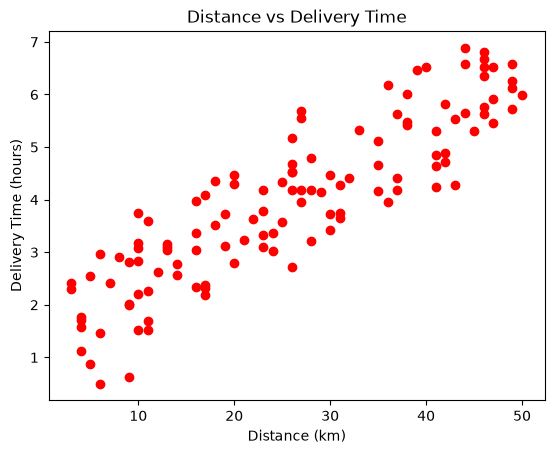

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df["Distance_km"], df["Delivery_Time_hr"],color = "Red")

plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (hours)")
plt.title("Distance vs Delivery Time")

plt.show()

In [9]:
correlation = df["Distance_km"].corr(df["Delivery_Time_hr"])

print("Correlation:", f"{correlation:2.2f}")

print("\n",pd.crosstab(df["Traffic_Level"], df["Delivery_Status"]))

Correlation: 0.89

 Delivery_Status  Delayed  On-Time
Traffic_Level                    
High                  30        0
Low                   24       25
Medium                33        8


In [10]:
traffic_delay_rate = pd.crosstab(
    df["Traffic_Level"],
    df["Delivery_Status"],
    normalize="index"
) * 100

print(traffic_delay_rate)

Delivery_Status     Delayed    On-Time
Traffic_Level                         
High             100.000000   0.000000
Low               48.979592  51.020408
Medium            80.487805  19.512195


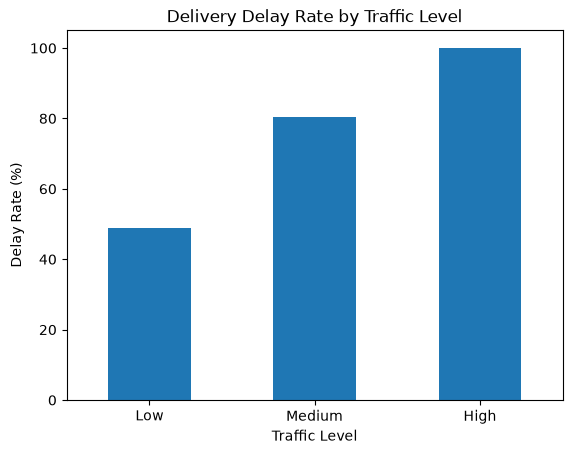

In [11]:
delay_rate = (
    df.groupby("Traffic_Level")["Delivery_Status"]
    .apply(lambda x: (x == "Delayed").mean() * 100)
)

delay_rate = delay_rate.reindex(["Low", "Medium", "High"])

delay_rate.plot(kind="bar")

plt.xlabel("Traffic Level")
plt.ylabel("Delay Rate (%)")
plt.title("Delivery Delay Rate by Traffic Level")
plt.xticks(rotation=0)
plt.show()

In [12]:
# Vehicle Type vs Average Delivery Cost
vehicle_cost = df.groupby("Vehicle_Type")["Delivery_Cost"].mean()
print("Average Delivery Cost by Vehicle Type:")
print(vehicle_cost.round(2))


Average Delivery Cost by Vehicle Type:
Vehicle_Type
Bike     173.29
Truck    220.91
Van      181.05
Name: Delivery_Cost, dtype: float64


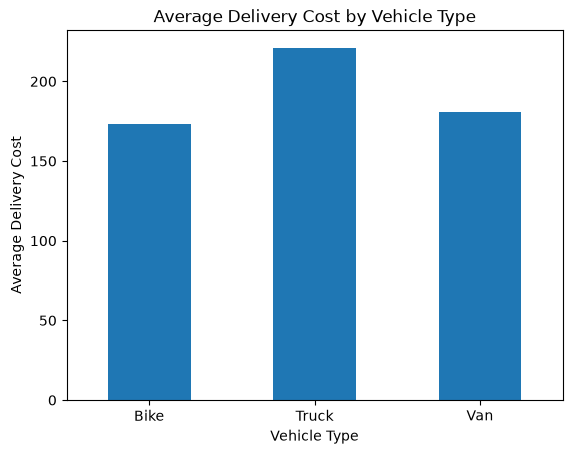

In [13]:
# Visualize average delivery cost by vehicle type
vehicle_cost.plot(kind="bar")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Cost")
plt.title("Average Delivery Cost by Vehicle Type")
plt.xticks(rotation=0)
plt.show()


In [14]:
# Weather vs Delivery Delay Rate
weather_delay = pd.crosstab(
    df["Weather"],
    df["Delivery_Status"],
    normalize="index"
) * 100

print("Weather vs Delivery Status (%):")
print(weather_delay.round(2))


Weather vs Delivery Status (%):
Delivery_Status  Delayed  On-Time
Weather                          
Clear              59.70    40.30
Fog                94.74     5.26
Rain               85.29    14.71


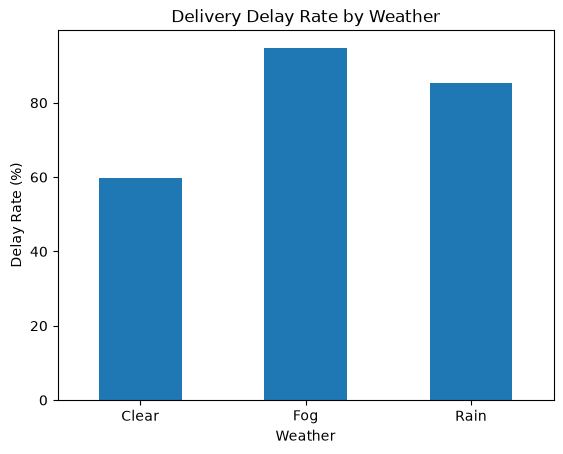

In [15]:
# Visualize delay rate by weather
weather_delay["Delayed"].plot(kind="bar")
plt.xlabel("Weather")
plt.ylabel("Delay Rate (%)")
plt.title("Delivery Delay Rate by Weather")
plt.xticks(rotation=0)
plt.show()


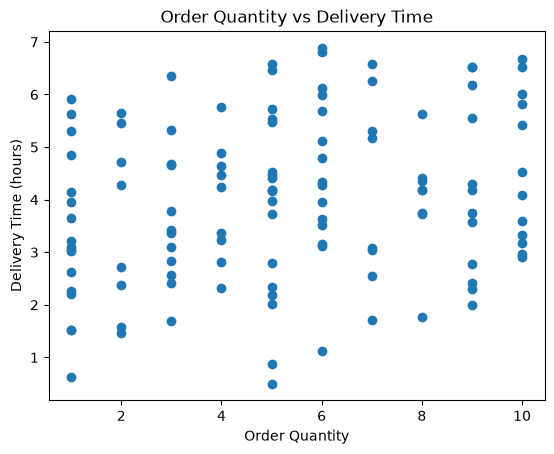

Order Quantity vs Delivery Time Correlation: 0.23


In [16]:
# Order Quantity vs Delivery Time
plt.scatter(df["Order_Quantity"], df["Delivery_Time_hr"])
plt.xlabel("Order Quantity")
plt.ylabel("Delivery Time (hours)")
plt.title("Order Quantity vs Delivery Time")
plt.show()

quantity_corr = df["Order_Quantity"].corr(df["Delivery_Time_hr"])
print("Order Quantity vs Delivery Time Correlation:", round(quantity_corr, 2))


In [17]:
# Calculate delay in hours
df["Delay_Hours"] = df["Delivery_Time_hr"] - df["Expected_Time_hr"]

print(df[[
    "Order_ID", "Expected_Time_hr", "Delivery_Time_hr", "Delay_Hours"
]].head())


   Order_ID  Expected_Time_hr  Delivery_Time_hr  Delay_Hours
0      1001              4.62              4.85         0.23
1      1002              4.22              4.27         0.05
2      1003              2.58              2.32        -0.26
3      1004              5.02              5.30         0.28
4      1005              2.24              3.09         0.85


In [18]:
# Find the 10 most delayed orders
most_delayed = df.sort_values("Delay_Hours", ascending=False)

print(most_delayed[[
    "Order_ID", "Delay_Hours", "Distance_km",
    "Traffic_Level", "Weather", "Vehicle_Type"
]].head(10))


    Order_ID  Delay_Hours  Distance_km Traffic_Level Weather Vehicle_Type
95      1096         1.87           27          High    Rain          Van
67      1068         1.58           20          High    Rain        Truck
37      1038         1.57           39          High     Fog         Bike
54      1055         1.39           10        Medium    Rain         Bike
44      1045         1.38           27          High     Fog        Truck
57      1058         1.37           16          High    Rain         Bike
30      1031         1.37           44          High   Clear         Bike
11      1012         1.34           26          High    Rain         Bike
14      1015         1.32           26        Medium    Rain          Van
74      1075         1.26           33          High    Rain         Bike


In [19]:
# KPI Summary
average_delivery_time = df["Delivery_Time_hr"].mean()
average_cost = df["Delivery_Cost"].mean()
on_time_rate = (df["Delivery_Status"] == "On-Time").mean() * 100
delay_rate = (df["Delivery_Status"] == "Delayed").mean() * 100

print("Average Delivery Time:", round(average_delivery_time, 2), "hours")
print("Average Delivery Cost:", round(average_cost, 2))
print("On-Time Delivery Rate:", round(on_time_rate, 2), "%")
print("Delay Rate:", round(delay_rate, 2), "%")


Average Delivery Time: 3.99 hours
Average Delivery Cost: 183.41
On-Time Delivery Rate: 27.5 %
Delay Rate: 72.5 %


In [20]:
# Prepare data for regression
model_df = pd.get_dummies(
    df[[
        "Distance_km",
        "Order_Quantity",
        "Traffic_Level",
        "Weather",
        "Vehicle_Type",
        "Delivery_Time_hr"
    ]],
    drop_first=True,
    dtype=int
)

X = model_df.drop("Delivery_Time_hr", axis=1)
y = model_df["Delivery_Time_hr"]

print("Features:")
print(X.columns.tolist())


Features:
['Distance_km', 'Order_Quantity', 'Traffic_Level_Low', 'Traffic_Level_Medium', 'Weather_Fog', 'Weather_Rain', 'Vehicle_Type_Truck', 'Vehicle_Type_Van']


In [21]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


Training records: 96
Testing records: 24


In [22]:
# Train Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("First 10 predictions:")
print(y_pred[:10])


First 10 predictions:
[5.59969923 3.92702034 2.83660977 6.05779613 3.10954188 5.67166538
 3.15278959 2.56107712 1.53578046 4.46929865]


In [23]:
# Evaluate the regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 3), "hours")
print("RMSE:", round(rmse, 3), "hours")
print("R² Score:", round(r2, 3))


MAE: 0.264 hours
RMSE: 0.335 hours
R² Score: 0.954


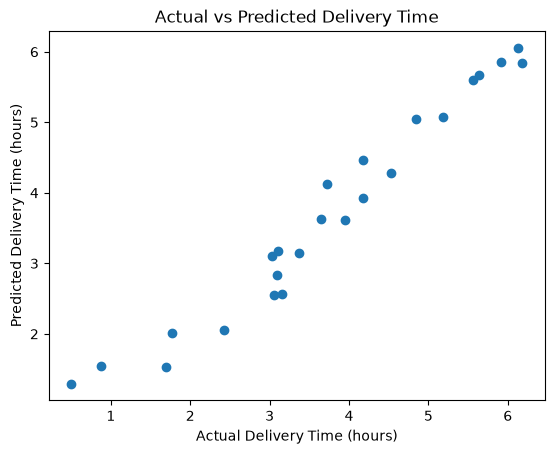

In [24]:
# Actual vs Predicted Delivery Time
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delivery Time (hours)")
plt.ylabel("Predicted Delivery Time (hours)")
plt.title("Actual vs Predicted Delivery Time")
plt.show()


In [25]:
# Prepare and scale clustering data
from sklearn.preprocessing import StandardScaler

cluster_data = df[[
    "Distance_km",
    "Order_Quantity",
    "Delivery_Cost"
]]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)


In [26]:
# Apply K-Means clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_data)

print(df[[
    "Order_ID", "Distance_km", "Order_Quantity",
    "Delivery_Cost", "Cluster"
]].head(10))


   Order_ID  Distance_km  Order_Quantity  Delivery_Cost  Cluster
0      1001           41               1         208.17        1
1      1002           31               6         225.78        1
2      1003           17               4         149.52        0
3      1004           45               1         245.65        1
4      1005           10               7         132.16        2
5      1006           23               9         152.16        2
6      1007           41               4         234.41        1
7      1008           21               4         136.67        0
8      1009           25               6         177.18        2
9      1010           13               3         115.67        0


In [27]:
# Understand what each cluster represents
cluster_summary = df.groupby("Cluster")[[
    "Distance_km",
    "Order_Quantity",
    "Delivery_Time_hr",
    "Delivery_Cost"
]].mean()

print(cluster_summary.round(2))


         Distance_km  Order_Quantity  Delivery_Time_hr  Delivery_Cost
Cluster                                                              
0              15.31            2.80              2.59         136.74
1              39.04            5.31              5.25         239.84
2              14.87            8.16              3.35         137.79
